Device: cuda
Converted pheno_onehot to np.float32 for 0 nodes.
Feature/label tensors:
  x: (2078, 5792)  y: (2078, 5)
  INPUT_DIMS: [766, 1930, 3096]
Loaded extra metadata: {'model': 'MOGSage', 'hidden_dim': 32, 'emb_dim': 16, 'seed': 7}


/home/bryan/miniconda3/envs/GTorchCu2.6/lib/python3.14/site-packages/torch_geometric/utils/convert.py:278: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  data_dict[key] = torch.as_tensor(value)


PyG data summary:
  num_nodes: 2078
  x shape:   (2078, 5792) dtype=torch.float32
  y shape:   (2078, 5) dtype=torch.float32
  edges:     19518
NeighborLoader config:
  batch_size:    64
  num_neighbors: [15, 10]
  shuffle:       False
  num_workers:   0
  pin_memory:    True
Targets: (2078, 4) using column 1 -> (2078,)


/home/bryan/miniconda3/envs/GTorchCu2.6/lib/python3.14/site-packages/captum/attr/_utils/batching.py:62: UserWarning: This method computes finite differences between evaluations at consecutive steps, so internal batch size must be at least twice the number of examples. Defaulting to internal batch size of 2954 equal to twice the number of examples.
  warnings.warn(
/home/bryan/miniconda3/envs/GTorchCu2.6/lib/python3.14/site-packages/captum/attr/_utils/batching.py:62: UserWarning: This method computes finite differences between evaluations at consecutive steps, so internal batch size must be at least twice the number of examples. Defaulting to internal batch size of 2828 equal to twice the number of examples.
  warnings.warn(
/home/bryan/miniconda3/envs/GTorchCu2.6/lib/python3.14/site-packages/captum/attr/_utils/batching.py:62: UserWarning: This method computes finite differences between evaluations at consecutive steps, so internal batch size must be at least twice the number of example

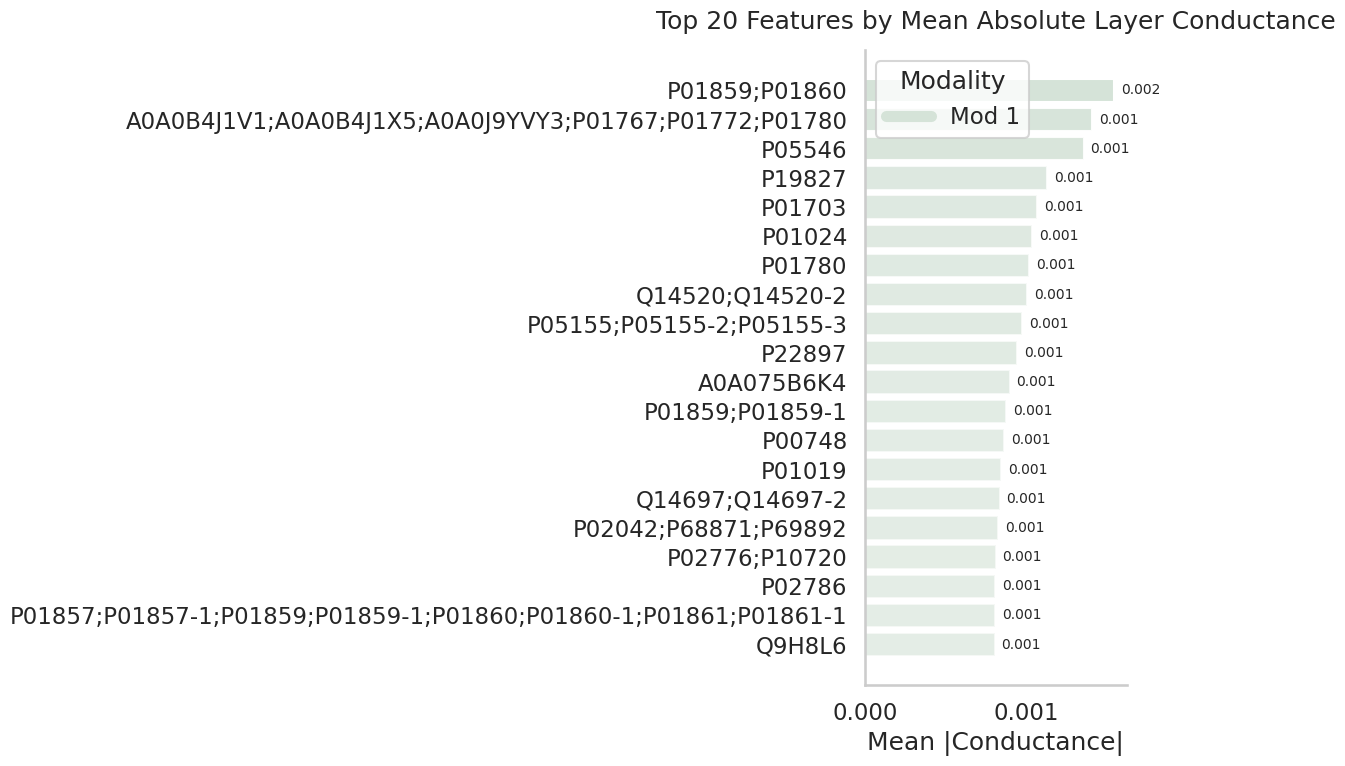

In [1]:
# ============================================================
# Identify Important Cluster Features
# ============================================================

import os, sys, pickle
from functools import reduce

import numpy as np
import pandas as pd
import torch

from torch_geometric.utils import from_networkx
from torch_geometric.loader import NeighborLoader

# ----------------------------
# Device
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# ----------------------------
# Paths / imports from your project
# ----------------------------
sys.path.insert(0, "./../MAIN/")

from gnn import MOGSage
from helpers import load_pytorch_model, merge_dfs
from network_functions import fix_pheno_onehot_in_graph, nx_to_pyg, load_graph, node_labels
from applications import visualise_feature_importance

# ============================================================
# CONFIG
# ============================================================
DATADIR       = "/work/gr-fe/bryan/data/SHCS/"
GPREFIX       = "KGshcs"
ATTRS_TO_KEEP = {"pheno_onehot"}
SEED          = 7

# Model
ENC_DIMS = [64,64,32]
LATENT_DIMS = [32,32,12]
DECODER_DIM = 32
GNN_DIMS = [32,16] 
DROPOUT      = 0.2
LR           = 1e-3
CHECKPOINT   = "/work/gr-fe/bryan/data/SHCS/03_final/mogsage_gnn_model.pth"

# Loader / importance
BATCH_SIZE      = 64
NUM_NEIGHBORS   = [15, 10]
SHUFFLE         = False
NUM_WORKERS     = 0   # best for notebooks
PIN_MEMORY      = (device == "cuda")
PERSIST_WORKERS = False

TARGET_PATH = "/work/gr-fe/bryan/data/SHCS/03_final/mogsage_cluster_membership.npy"
TARGET_COL  = 1

TOP_N       = 20
PLOT_TITLE  = "Top 20 Features by Mean Absolute Layer Conductance"

# ----------------------------
# Reproducibility (optional; keep if your pipeline is stochastic)
# ----------------------------
torch.manual_seed(SEED)
np.random.seed(SEED)
if device == "cuda":
    torch.cuda.manual_seed_all(SEED)

# ============================================================
# 1) LOAD GRAPH
# ============================================================
g = load_graph(os.path.join(DATADIR, "Networks", f"{GPREFIX}_psn.gpickle"), "PSN")
cnt = fix_pheno_onehot_in_graph(g)
print(f"Converted pheno_onehot to np.float32 for {cnt} nodes.")

# Keep your original helpers (even if you don't use outputs later)
ei, order, weight = nx_to_pyg(g, ATTRS_TO_KEEP, get_weight=True)
all_nodes = sorted(set(g.nodes))

# ============================================================
# 2) LOAD FEATURES / LABELS
# ============================================================
expr_dfs = []
for expr in ['Proteomics' , 'Metabolomics' , 'PGS'] :
    with open(os.path.join(DATADIR, "02_processed", f"{expr}.processed.pkl"), "rb") as f:
        data_expr = pickle.load(f)
    expr_df = data_expr["expr"]
    expr_dfs.append(expr_df.loc[expr_df.index.intersection(all_nodes)].copy())

meta = node_labels(g)
meta = pd.DataFrame(np.float32(meta.values), index=meta.index)

h_df    = reduce(merge_dfs, expr_dfs).reindex(all_nodes)
meta_df = meta.reindex(all_nodes)

x = torch.tensor(h_df.values,    dtype=torch.float32)

nan_mask = torch.isnan(x)

# Replace NaNs with +inf so they sort to the end, then take median of non-NaNs
# Step 1: sort along rows (dim=0) to compute per-column medians
X_filled = x.clone()
X_filled[nan_mask] = float("inf")
X_sorted, _ = X_filled.sort(dim=0)

# Count non-NaNs per column
counts = (~nan_mask).sum(dim=0)  # shape (D,)

# Median index per column (lower median for even counts; you can change this)
median_idx = (counts - 1) // 2   # shape (D,)

# Gather per-column medians
D = x.shape[1]
medians = X_sorted[median_idx, torch.arange(D)]  # shape (D,)

# Impute
x[nan_mask] = medians.expand_as(x)[nan_mask]
y = torch.tensor(meta_df.values, dtype=torch.float32)

INPUT_DIMS = [df.shape[1] for df in expr_dfs]

print("Feature/label tensors:")
print(f"  x: {tuple(x.shape)}  y: {tuple(y.shape)}")
print(f"  INPUT_DIMS: {INPUT_DIMS}")

# ============================================================
# 3) BUILD MODEL + LOAD CHECKPOINT
# ============================================================
model = MOGSage(
    input_dims=INPUT_DIMS,
    encoder_dims=ENC_DIMS,
    latent_dims=LATENT_DIMS,
    decoder_dim=DECODER_DIM,
    hidden_dims=GNN_DIMS,
    num_classes=y.shape[1],
    dropout=DROPOUT,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

model, optimizer, extra, checkpoint = load_pytorch_model(
    model=model,
    model_path=CHECKPOINT,
    optimizer=optimizer,
    map_location=device,
)

model.eval()
print("Loaded extra metadata:", extra)

# ============================================================
# 4) PyG DATA + LOADER
# ============================================================
data = from_networkx(g)
data.x = x.float()
data.y = y.float()

print("PyG data summary:")
print(f"  num_nodes: {data.num_nodes}")
print(f"  x shape:   {tuple(data.x.shape)} dtype={data.x.dtype}")
print(f"  y shape:   {tuple(data.y.shape)} dtype={data.y.dtype}")
if hasattr(data, "edge_index"):
    print(f"  edges:     {data.edge_index.size(1)}")

loader = NeighborLoader(
    data,
    batch_size=BATCH_SIZE,
    shuffle=SHUFFLE,
    num_neighbors=NUM_NEIGHBORS,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSIST_WORKERS,
)

print("NeighborLoader config:")
print(f"  batch_size:    {BATCH_SIZE}")
print(f"  num_neighbors: {NUM_NEIGHBORS}")
print(f"  shuffle:       {SHUFFLE}")
print(f"  num_workers:   {NUM_WORKERS}")
print(f"  pin_memory:    {PIN_MEMORY}")

# ============================================================
# 5) TARGET CLASSES + FEATURE IMPORTANCE
# ============================================================
target_classes = np.load(TARGET_PATH)

if target_classes.shape[0] != data.num_nodes:
    raise ValueError(
        f"target_classes has {target_classes.shape[0]} rows, but data has {data.num_nodes} nodes. "
        "This usually indicates node-order mismatch between your saved targets and PyG node ordering."
    )

target_classes = torch.tensor(target_classes, dtype=torch.float32)
if TARGET_COL >= target_classes.shape[1]:
    raise IndexError(
        f"TARGET_COL={TARGET_COL} out of bounds for target_classes with {target_classes.shape[1]} columns."
    )

target_vec = target_classes[:, TARGET_COL]
print(f"Targets: {tuple(target_classes.shape)} using column {TARGET_COL} -> {tuple(target_vec.shape)}")

with torch.no_grad():
    importances = model.feature_importance(
        loader=loader,
        device=device,
        target_label=0,
    )

# Optional: attach names if returned as a DataFrame (depends on your implementation)
if isinstance(importances, pd.DataFrame):
     importances.columns = h_df.columns

# ============================================================
# 6) VISUALISE
# ============================================================
fig, _, df_plot = visualise_feature_importance(
    importances,
    top_n=TOP_N,
    title=PLOT_TITLE,
    mod_dim=[766,1930,3096]
)


In [2]:
top_prot = list(importances.var()[:766].sort_values(ascending=False)[:5].index)
top_meta = list(importances.var()[766:766+1930].sort_values(ascending=False)[:5].index)
top_pgs = list(importances.var()[766+1930:].sort_values(ascending=False)[:5].index)

In [ ]:
fig, _, df_plot = visualise_feature_importance(
    importances[top_prot  + top_meta + top_pgs],
    top_n=15,
    title=PLOT_TITLE,
    mod_dim=[5,5,5]
)

In [25]:
fig.savefig('top_feats.svg')